# Stage 5: Feature Engineering Pipeline
Build the complete feature matrix for modelling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append('../')
from src.features import compute_momentum_features, compute_volatility_features, compute_volume_features, compute_microstructure_features, compute_entropy_features, build_feature_matrix

plt.style.use('seaborn-v0_8-darkgrid')


## 1. Load Data


In [2]:
df = pd.read_parquet('../data/processed/nvda_clean.parquet')
fracdiff = pd.read_parquet('../data/processed/nvda_fracdiff.parquet')
events = pd.read_parquet('../data/processed/nvda_cusum_events.parquet')
labels = pd.read_parquet('../data/processed/nvda_labels.parquet')
weights = pd.read_parquet('../data/processed/nvda_sample_weights.parquet')

print("Loaded all datasets.")


Loaded all datasets.


## 2 & 3. Compute Features and Build Final Dataset


In [3]:
modelling_dataset = build_feature_matrix(df, fracdiff, events, labels, weights)
modelling_dataset.head()


,ret_5d,ret_10d,ret_20d,ret_60d,momentum_12_1,rsi_14,vol_20d,vol_50d,log_dollar_volume,volume_ratio,corwin_schultz_spread,bekker_parkinson_vol,amihud_illiquidity,roll_spread,shannon_entropy,lempel_ziv_complexity,fracdiff,label,weight,t1
2018-10-10,-0.154470,-0.082878,-0.087662,-0.031495,0.369843,31.968566,0.409506,0.331205,22.150624,1.810514,-0.042694,0.001711,5.977717e-12,0.000000,1.729467,1.0,-0.480020,-1.0,1.370556,2018-10-22
2018-10-24,-0.197945,-0.208708,-0.291586,-0.204777,0.303301,24.521598,0.636498,0.464595,22.197368,1.773130,-0.017704,0.004158,9.541217e-12,0.000000,1.818226,1.0,-0.421655,1.0,0.775113,2018-11-05
2018-10-29,-0.219668,-0.237500,-0.443970,-0.305578,0.333332,24.702697,0.629751,0.494478,21.971628,1.403350,0.018851,0.007923,1.073727e-11,0.239180,1.916478,1.0,-0.406250,1.0,1.220275,2018-11-08
2018-10-30,-0.085228,-0.191435,-0.344463,-0.223700,0.352817,35.389969,0.744002,0.537319,22.123989,1.438053,0.062639,0.003018,1.165645e-11,0.288170,1.853464,1.0,-0.377417,1.0,1.104102,2018-11-09
2018-11-12,-0.110901,0.020898,-0.216601,-0.255376,0.134079,32.569574,0.747329,0.565019,21.786879,1.082051,-0.050293,0.001902,1.150229e-11,0.164923,1.844569,1.0,-0.362839,1.0,1.072145,2018-11-23


## 4. Summary Statistics


In [4]:
print(f"Final Dataset Shape: {modelling_dataset.shape}")
print("\nColumns:", modelling_dataset.columns.tolist())

print("\nSummary Statistics:")
display(modelling_dataset.describe())


Final Dataset Shape: (171, 20)

Columns: ['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'momentum_12_1', 'rsi_14', 'vol_20d', 'vol_50d', 'log_dollar_volume', 'volume_ratio', 'corwin_schultz_spread', 'bekker_parkinson_vol', 'amihud_illiquidity', 'roll_spread', 'shannon_entropy', 'lempel_ziv_complexity', 'fracdiff', 'label', 'weight', 't1']

Summary Statistics:


,ret_5d,ret_10d,ret_20d,ret_60d,momentum_12_1,rsi_14,vol_20d,vol_50d,log_dollar_volume,volume_ratio,corwin_schultz_spread,bekker_parkinson_vol,amihud_illiquidity,roll_spread,shannon_entropy,lempel_ziv_complexity,fracdiff,label,weight,t1
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,1.710000e+02,171.000000,171.000000,171.0,171.000000,171.000000,171.000000,171
mean,-0.027412,-0.024951,-0.026328,0.002403,0.381640,48.738705,0.652115,0.600791,23.233473,1.410254,-0.050598,0.002023,4.856932e-12,0.900301,1.924832,1.0,-0.276098,0.134503,1.173619,2022-02-04 11:13:41.052631552
min,-0.269937,-0.380838,-0.468707,-0.744951,-0.972262,24.521598,0.300299,0.297254,21.404944,0.693019,-0.477620,0.000309,5.315832e-13,0.000000,1.178720,1.0,-0.681575,-1.000000,0.040480,2018-10-22 00:00:00
25%,-0.101837,-0.119405,-0.143022,-0.205868,0.028887,37.934267,0.546803,0.497595,22.556591,1.057316,-0.085756,0.001000,1.815482e-12,0.000000,1.817532,1.0,-0.399714,-1.000000,0.795946,2020-05-15 00:00:00
50%,-0.032211,-0.032342,-0.040796,0.003777,0.479804,45.628058,0.625230,0.599798,23.123290,1.250038,-0.041424,0.001518,3.343528e-12,0.240222,1.957494,1.0,-0.293657,1.000000,1.133090,2022-04-04 00:00:00
75%,0.053725,0.058462,0.105337,0.253662,0.800722,56.613613,0.736021,0.695799,23.998128,1.650812,0.006174,0.002352,6.722288e-12,0.716517,2.045124,1.0,-0.162475,1.000000,1.485104,2023-04-20 12:00:00
max,0.209337,0.284423,0.386620,0.647857,1.298303,88.175311,1.396894,1.030086,25.327677,4.191627,0.102158,0.009896,1.680870e-11,8.211658,2.186136,1.0,0.157875,1.000000,3.008112,2025-04-28 00:00:00
std,0.104638,0.134738,0.185175,0.295039,0.531221,13.907209,0.199711,0.148919,0.980396,0.542096,0.080761,0.001699,4.333817e-12,1.702348,0.180613,0.0,0.166789,0.993823,0.547286,NaN


## 5. Feature Correlation Heatmap


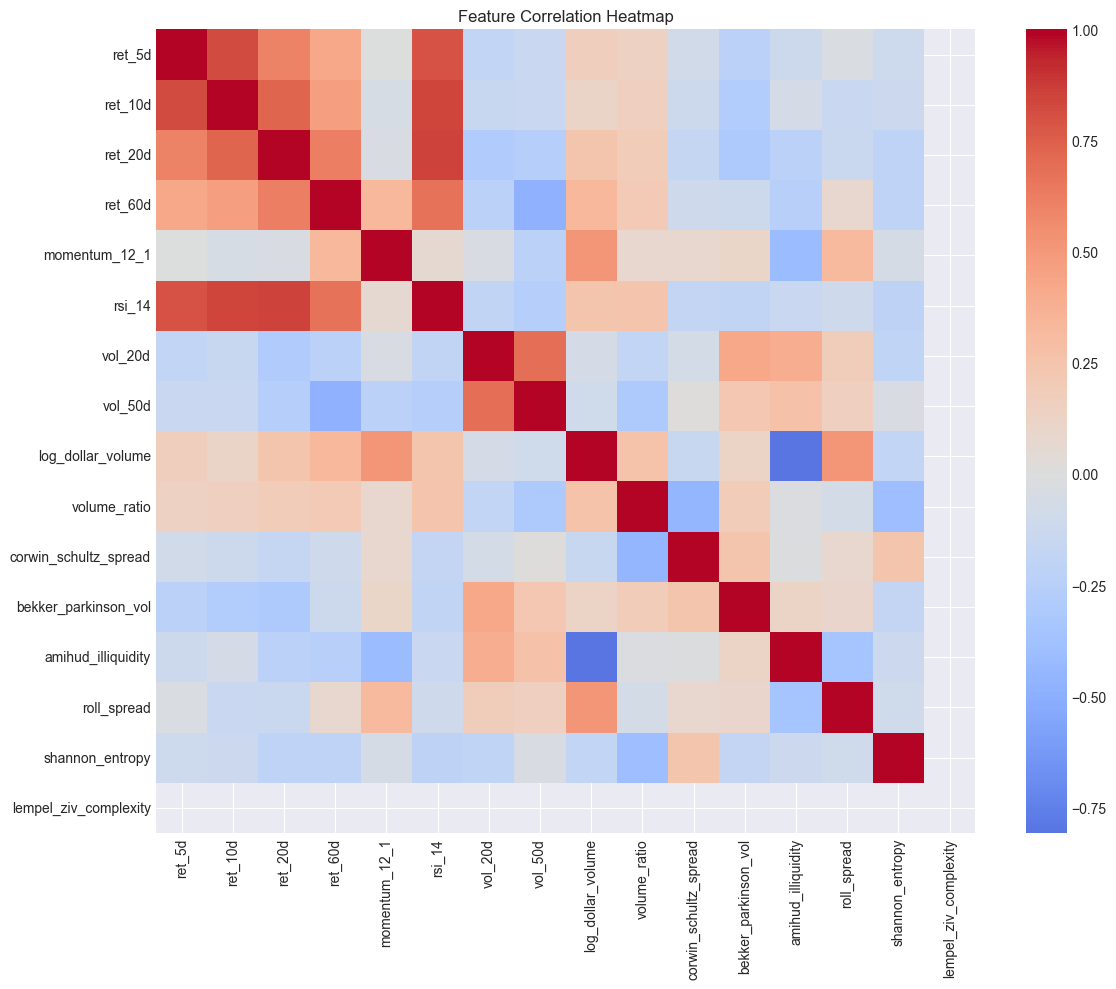

In [5]:
# Extract just the features (excluding labels, weights, t1, etc.)
feature_cols = [c for c in modelling_dataset.columns if c not in ['label', 'weight', 't1', 'fracdiff']]
features_only = modelling_dataset[feature_cols]

corr_matrix = features_only.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 6. Check for NaNs and Inf


In [6]:
print("Checking for NaNs:")
print(modelling_dataset.isna().sum())

print("\nChecking for Inf:")
print(np.isinf(modelling_dataset.select_dtypes(include=[np.number])).sum())


Checking for NaNs:
ret_5d                   0
ret_10d                  0
ret_20d                  0
ret_60d                  0
momentum_12_1            0
rsi_14                   0
vol_20d                  0
vol_50d                  0
log_dollar_volume        0
volume_ratio             0
corwin_schultz_spread    0
bekker_parkinson_vol     0
amihud_illiquidity       0
roll_spread              0
shannon_entropy          0
lempel_ziv_complexity    0
fracdiff                 0
label                    0
weight                   0
t1                       0
dtype: int64

Checking for Inf:
ret_5d                   0
ret_10d                  0
ret_20d                  0
ret_60d                  0
momentum_12_1            0
rsi_14                   0
vol_20d                  0
vol_50d                  0
log_dollar_volume        0
volume_ratio             0
corwin_schultz_spread    0
bekker_parkinson_vol     0
amihud_illiquidity       0
roll_spread              0
shannon_entropy          0
lemp

## 7. Save Outputs


In [7]:
features_only.to_parquet('../data/processed/nvda_features.parquet')
modelling_dataset.to_parquet('../data/processed/nvda_modelling_dataset.parquet')
print("Saved nvda_features.parquet and nvda_modelling_dataset.parquet")


Saved nvda_features.parquet and nvda_modelling_dataset.parquet
